# Module 2 Part 1: RL models
In this tutorial we will learn how to implement agents that make decisions that are based on their previous experience.

The code is related to:

Bob Wilson & Anne Collins (2019) eLife: Ten simple rules for the computational modeling of behavioral data.

In this paper, the authors describe a 2-armed bandit, where a player performs $T$ choices between two options. The machine has asymmetric reward probabilities $\mu_{1} = 0.2$ and $\mu_{2} = 0.8$ associated with each arm, which are initially unknown to the player.

We want to find out: Which strategy does a subject use to maximize their overall reward on this machine?

## 1. Setting up our modelling framework

Let's start by setting up a class we can use going forward.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# set numpy seed to 0
np.random.seed(0)

# To implement RLModel, define `simulate()`, `likelihood()`, and `initial_parameters()`.  See below for win-stay lose-switch as an example.
class RLModel:
    def simulate(self, T, mu, pars):
        """Simulate a trace with the given switch probabilities.

        T: the number of timesteps to simulate
        mu: A list of length 2 with the reward probabilities of each arm
        pars: A list of parameters, same length as `initial_parameters()` and `parameter_bounds()`

        Returns a 2-tuple of lists of length T, the first of choices (0 or 1) and the second of whether the trial was rewarded (0 or 1)
        """
        raise NotImplementedError("You need to define this!")
    def likelihood(self, pars, a, r):
        """Determine the likelihood of a trace

        pars: A list of parameters, same length as `initial_parameters()` and `parameter_bounds()`
        a: a list of choices (0 or 1) of the same length as `r`
        r: a list of whether each trial was rewarded (0 or 1) of the same length as `a`

        Returns the negative log likelihood of these data under the parameters
        """
        raise NotImplementedError("You need to redefine this in subclasses!")
    def initial_parameters(self):
        """Return a list of floats, of length # parameters, containing their initial values"""
        raise NotImplementedError("You need to redefine this in subclasses!")
    def parameter_bounds(self):
        """Return a list of 2-tuples, of length # parameters, containing the bounds for the parameter search"""
        raise NotImplementedError("You need to redefine this in subclasses!")
    def fit(self, a, r): # You don't need to redefine this for new models
        """Fit parameters to the model for the given data with maximum likelihood

        a: a list of choices (0 or 1) of the same length as `r`
        r: a list of whether each trial was rewarded (0 or 1) of the same length as `a`

        Returns a 3-tuple, with elements:
           BIC
           list of parameters, same length as `initial_parameters()` and `parameter_bounds()`, optimised for these data
           log likelihood
        """
        x0 = self.initial_parameters()
        bounds = self.parameter_bounds()

        res = scipy.optimize.minimize(self.likelihood, args=(a, r), method='L-BFGS-B', x0=x0, bounds=bounds)

        bic = len(x0) * np.log(len(a)) + 2 * res.fun
        return bic, res.x, -res.fun  # BIC, parameters, log-likelihood



## 2. Build and simulate our candidate models

We will consider three candidate descriptive process models of how subjects might behave on a 2-armed bandit. You can read the mathematical formulation of each model in the paper. Briefly, the proposed models are:

- **Noisy win-stay-lose-switch**: With probability $1-\epsilon$, the subject follows the deterministic win-stay-lose-switch rule. With probability $\epsilon$, they choose uniformly at random between the two arms. Thus, in this two-arm implementation, the probability of following the rule is $1-\epsilon/2$. If $\epsilon=0$, the model is deterministic win-stay-lose-switch. (Model 2 in the paper, with 1 parameter: $\epsilon$, describing the overall level of randomness.)

- **Rescorla Wagner**: In each trial, subjects update the expected values of each option (Q), based on the history of previous outcome. Then, they use these values to make the next decision. They make a choice based on the relative expected value of each option, passed through a softmax function.  (model 3 in the paper, with 2 parameters: learning rate $\alpha_{RW}$, and softmax inverse temperature $\beta_{RW}$)

- **Choice kernel**: Subjects have a tendency to repeat responses.  In this model, their next response depends only on their previous responses, with the probability of their next response being proportional to the time-weighted response history.  This history is tracked in the "choice kernel".  This is very similar to Rescorla-Wagner, except instead of tracking estimates of the values, they track their own choice history without estimating value. (model 4 in the paper, with 2 parameters: choice-kernel learning rate $\alpha_{CK}$, and choice-kernel inverse temperature $\beta_{CK}$).

### 2.1 Implement win-stay lose-switch

First we'll show an example of the win-stay lose-switch model as a demonstration.

In [2]:
class WinStayLoseSwitch(RLModel):
    def simulate(self, T, mu, pars):
        """Simulate a trace with the given uniform-lapse probability.

        T: the number of timesteps to simulate
        mu: A list of length 2 with the reward probabilities of each arm
        pars: A list of parameters, same length as `initial_parameters()` and `parameter_bounds()`

        Returns a 2-tuple of lists of length T, the first of choices (0 or 1) and the second of whether the trial was rewarded (0 or 1)
        """
        epsilon = pars[0]
        # Keep choices in list a (elements are 0 or 1) and rewards in list r (0 unrewarded, 1 rewarded)
        a = [np.random.choice(2)] # Our first choice should be random
        r = [float(np.random.random() < mu[a[0]])] # Random reward according to choice probabilities

        # Follow deterministic win-stay-lose-switch with probability 1-epsilon.
        # With probability epsilon, choose uniformly between both arms. Therefore,
        # the rule-consistent action has probability 1-epsilon/2.
        for _ in range(T - 1):
            if r[-1] == 1:  # win-stay
                p = [epsilon / 2, epsilon / 2]
                p[a[-1]] = 1 - epsilon / 2
            else:  # lose-shift
                p = [1 - epsilon / 2, 1 - epsilon / 2]
                p[a[-1]] = epsilon / 2

            # Calculate choices based on choice probabilities computed above
            a.append(np.random.choice(2, p=p))
            r.append(float(np.random.random() < mu[a[-1]]))

        return np.array(a), np.array(r)

    def likelihood(self, pars, a, r):
        """Determine the likelihood of a trace

        pars: A list of parameters, same length as `initial_parameters()` and `parameter_bounds()`
        a: a list of choices (0 or 1) of the same length as `r`
        r: a list of whether each trial was rewarded (0 or 1) of the same length as `a`

        Returns the negative log likelihood of these data under the parameters
        """
        epsilon = pars[0]
        # choice_p keeps track of the probability of making each choice.  We will use
        # these later to compute the likelihood
        choice_p = [0.5]

        # Given the parameter epsilon, we find the probability of making the choice
        # given whether the previous trial was rewarded
        for t in range(1, len(a)):
            if r[t-1] == 1:
                p = [epsilon / 2, epsilon / 2]
                p[a[t-1]] = 1 - epsilon / 2
            else:
                p = [1 - epsilon / 2, 1 - epsilon / 2]
                p[a[t-1]] = epsilon / 2

            choice_p.append(p[a[t]])

        # Sum the logs (the numerically stable version of multiplying the probabilities
        # and then taking the log)
        return -np.sum(np.log(np.array(choice_p) + 1e-5))

    def initial_parameters(self):
        # There is only one parameter in this model, so we return a list of length 1.
        # This is the epsilon parameter.  We don't know what it is, so guess with a number
        # between 0 and 1.
        return [np.random.random()]

    def parameter_bounds(self):
        # There is only one parameter in this model, so we return a list of length 1
        # This is the epsilon parameter, and must be between 0 and 1.
        return [(0, 1)]




Now test the model.  We're going to do a simple parameter recovery experiment to make sure our simulation, likelihood, and fitting is working correctly.

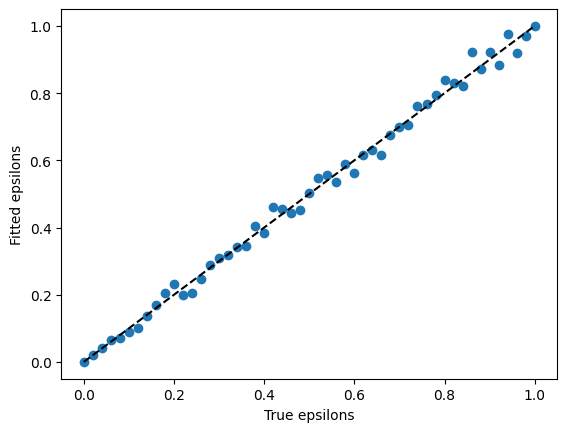

In [3]:
import numpy as np
import matplotlib.pyplot as plt
wsls_model = WinStayLoseSwitch()

epsilons = np.linspace(0, 1, 51)
T = 1000
mu = [.8, .2]
fitted_epsilons = []
for epsilon in epsilons:
    data_a, data_r = wsls_model.simulate(T, mu, [epsilon])
    _,fitted,_ = wsls_model.fit(data_a, data_r)
    fitted_epsilons.append(fitted[0])

plt.scatter(epsilons, fitted_epsilons)
plt.xlabel("True epsilons")
plt.ylabel("Fitted epsilons")
plt.plot([0, 1], [0, 1], c='k', linestyle='--')

### 2.2 Rescorla-Wagner

Now it's your turn!  Implement Rescorla-Wagner.  Use the win-stay-lose-switch as an example.  Fill out the sections below.

In [4]:
class RescorlaWagner(RLModel):
    def simulate(self, T, mu, pars):
        alpha = pars[0]
        beta = pars[1]
        # Initialise our Q values to 0.5
        Q = np.array([0.5, 0.5])
        a, r = [], [] # a = choices, r = rewards

        # FILL ME IN!

        return np.array(a), np.array(r)

    def likelihood(self, pars, a, r):
        alpha = pars[0]
        beta = pars[1]
        Q = np.array([0.5, 0.5]) # Initialise Q values to 0.5
        choice_p = []

        # FILL ME IN!
        
        return nLL

    def initial_parameters(self):
        # Two parameters: alpha (learning rate) and beta (softmax inverse temperature)
        
        # FILL ME IN
        
        return initial_params

    def parameter_bounds(self):
        # Two parameters: alpha (learning rate) and beta (softmax inverse temperature)
        
        # FILL ME IN
        
        return bounds

And now, validate the model.  Note that there are two parameters we need to keep track of here for our model recovery.  There are many ways to do this, choose a strategy here that will give you confidence your model is correct.  Note that you might need a longer T than we did in win-stay-lose-switch, since there are two parameters to estimate.  Also note that sometimes the fitting might fail and give an incorrect result; this is something you always need to watch out for when fitting models!

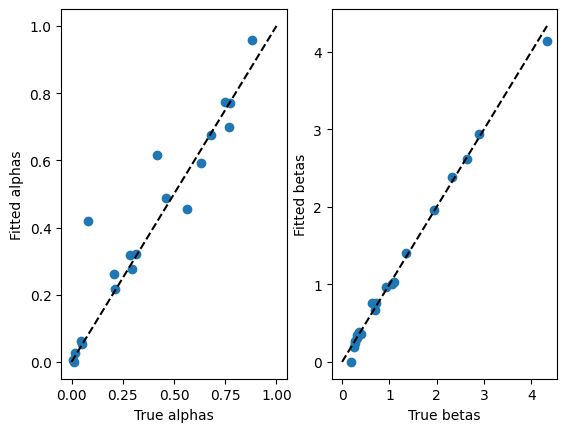

In [5]:
rw_model = RescorlaWagner()
params = [rw_model.initial_parameters() for _ in range(0, 20)]
T = 5000
mu = [.8, .2]
fitted_params = []

# FILL ME IN!

plt.subplot(1,2,1)
plt.scatter([p[0] for p in params], [p[0] for p in fitted_params])
plt.xlabel("True alphas")
plt.ylabel("Fitted alphas")
plt.plot([0, 1], [0, 1], c='k', linestyle='--')

maxval = np.max([p[1] for p in params+fitted_params])
plt.subplot(1,2,2)
plt.scatter([p[1] for p in params], [p[1] for p in fitted_params])
plt.xlabel("True betas")
plt.ylabel("Fitted betas")
plt.plot([0, maxval], [0, maxval], c='k', linestyle='--')

### 2.3 Choice kernel

Now, implement the final model we will compare, the choice kernel model.

In [6]:
class ChoiceKernel(RLModel):
    def simulate(self, T, mu, pars):
        alpha = pars[0]
        beta = pars[1]
        CK = np.full(2, 0.001) # Start with small uniform values
        a, r = [], []

        # FILL ME IN!

        return np.array(a), np.array(r)

    def likelihood(self, pars, a, r):
        alpha, beta = pars
        CK = np.full(2, 0.001) # Start with small uniform values
        choice_p = []

        # FILL ME IN!

        return -np.sum(np.log(np.array(choice_p) + 1e-5))

    def initial_parameters(self):
        # Params: alpha (learning rate) and beta (softmax inverse temperature)
        return [np.random.random(), 0.5 + np.random.exponential()]

    def parameter_bounds(self):
        # Params: alpha (learning rate) and beta (softmax inverse temperature)
        return [(0, 1), (0, np.inf)]


And again, do a simple parameter recovery to make sure the model is working.

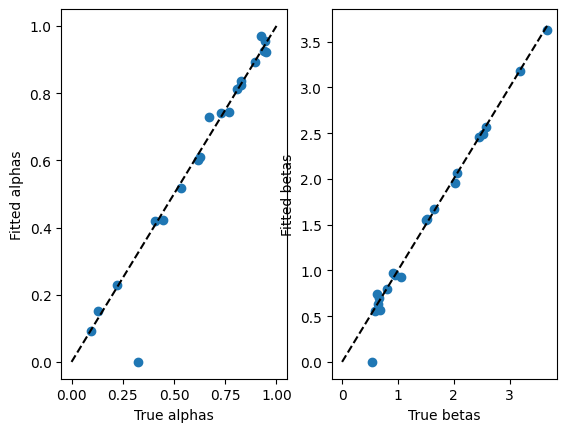

In [7]:
ck_model = ChoiceKernel()
params = [ck_model.initial_parameters() for _ in range(0, 20)]
T = 5000
mu = [.8, .2]
fitted_params = []

# FILL ME IN!

plt.subplot(1,2,1)
plt.scatter([p[0] for p in params], [p[0] for p in fitted_params])
plt.xlabel("True alphas")
plt.ylabel("Fitted alphas")
plt.plot([0, 1], [0, 1], c='k', linestyle='--')

maxval = np.max([p[1] for p in params+fitted_params])
plt.subplot(1,2,2)
plt.scatter([p[1] for p in params], [p[1] for p in fitted_params])
plt.xlabel("True betas")
plt.ylabel("Fitted betas")
plt.plot([0, maxval], [0, maxval], c='k', linestyle='--')

### 2.4 Simulate the models

Next, let's simulate lots of experiments from the models that we can analyse in the upcoming sections. Use these parameters for the models:

- Win Stay Lose Shift: $\epsilon=0.1$
- Rescorla Wagner: $\alpha_{RW}=0.1$ and $\beta_{RW}=3$
- Choice Kernel: $\alpha_{CK}=0.1$ and $\beta_{CK}=3$

Save the results in the lists a_wsls/a_rw/a_ck for the actions/choices, and r_wsls/r_rw/r_ck for the rewards from each of those actions.  Each of these should be a list of lists, with lots of simulated experiments from each model.

In [8]:
# Experiment parameters
num_trials = 100
reward_probabilities = np.array([0.2, 0.8])
num_repetitions = 110

# define a function to simulate the models and collect data
def simulate_model(model, num_reps, num_trials, reward_probs, params):
    actions, rewards = [], []
    
    # FILL ME IN!
    
    return actions, rewards

# Simulate models
a_wsls, r_wsls = simulate_model(wsls_model, num_repetitions, num_trials, reward_probabilities, [0.1])
a_rw, r_rw = simulate_model(rw_model, num_repetitions, num_trials, reward_probabilities, [0.1, 3])
a_ck, r_ck = simulate_model(ck_model, num_repetitions, num_trials, reward_probabilities, [0.1, 3])

For each model, you should also play with the parameters used to generate the simulations and observe the effect on Win-Stay-Lose-Shift analysis (see below).

## 3. Behavioral analyses: Visualise the behaviour of different simulated models.

We will now observe the behavioral outcomes resulting from each simulation. A typical analysis that might allow you to compare qualitatively the model behavior with actual subjects playing the 2-armed bandit is a win-stay-lose-shift analysis that plots the probability of repeating an action, p(stay), as a function of the previous reward (see Wilson & Collins, box 2 figure 1).

### 3.1 Compare qualitative patterns from our three different models

Collect win-stay-lose-shift behavior for all three models.

Write a function that calculates $p(stay_{n} | win_{n-1} = 0)$ and $p(stay_{n} | win_{n-1} = 1)$ from a single sequence of simulated actions and rewards.

Then, average probabilities across simulations for each model.

In [9]:
def compute_stay_probabilities(actions, rewards):
    """Compute probability of stay given win/lose.

    actions: a list of choices/actions (e.g., `a` from `model.simulate()`)
    rewards: a list of rewards corresponding to those actions (e.g., `r` from `model.simulate()`)

    Returns a 2-tuple containing the probability of staying given lose and win
    """

    # FILL ME IN!
    
    return lose_stay, win_stay

Now plot WSLS behavior as a function of previous reward (1 for rewarded, 0 for unrewarded).  For each model, are we more likely to stay or switch as a function of the previous reward?

(0.0, 1.0)

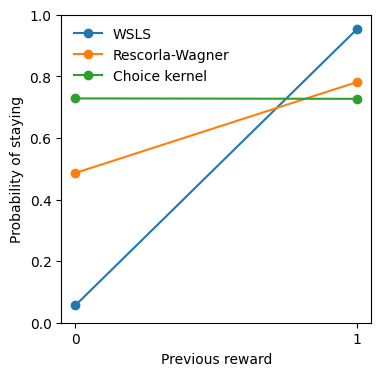

In [10]:
# Calculate WSLS for each model
model_actions = [a_wsls, a_rw, a_ck]
model_rewards = [r_wsls, r_rw, r_ck]
model_names = ['WSLS', 'Rescorla-Wagner', 'Choice kernel']

wsls_probs = []
for actions, rewards in zip(model_actions, model_rewards):
    wsls_probs.append(np.mean([compute_stay_probabilities(actions[n], rewards[n]) for n in range(num_repetitions)], axis=0))

# Plot WSLS as a function of previous reward
plt.figure(figsize=(4, 4), dpi=100)
for i, prob in enumerate(wsls_probs):
    plt.plot([0, 1], prob, 'o-', label=model_names[i])
plt.xlabel('Previous reward')
plt.ylabel('Probability of staying')
plt.xticks([0, 1])
plt.legend(frameon=False)
plt.ylim(0, 1)

You should see that the choice kernel model leads to a reward-independent $p(stay)$, because choice probabilities are calculated independently of the previous reward. All other models show outcome-modulated behavior, with the starkest differences for the WSLS simulation.

*Take home message*: More broadly, these patterns of behavior can then be contrasted against actual behavioral data to inform about subjects' behavior. It is important to simulate your candidate models and plot their behavior before comparing them to actual data.

### 3.2 Let's analyse the performance of the Rescorla Wagner Model: p(correct) analysis

For Rescorla-Wagner, we are now interested in how learning rate and softmax inverse temperature affect the probability of choosing the arm with the highest reward.

We will repeatedly perform a grid search over different parameter values (Nreps simulations with 100 trials per grid point) and store the mean $p(correct)$ across trials for each grid point and repetition.

In [11]:
# Parameter grid search for Rescorla-Wagner model
alphas = np.linspace(0.02, 1, 4)
betas = np.array([1, 2, 5, 10, 20])

In [12]:
# Let's first use only 10 simulations for each parameter combination. When your code works, increase to 1000.
num_reps = 10# 1000

# Initialize arrays to collect data
correct = np.zeros((len(alphas), len(betas), num_reps)) # The overall correct probability
correct_early = np.zeros((len(alphas), len(betas), num_reps)) # The probability of correct in the first 10 trials
correct_late = np.zeros((len(alphas), len(betas), num_reps)) # The probability of correct in the last 10 trials

# Evaluation loop: grid-search over alpha and beta parameters for a large number of simulations
# on which you will then average.  Fill up the arrays above with the results, and then the plotting
# code in the next section will work.

# FILL ME IN!

Now plot $p(correct)$ as a function of $\alpha$ and $\beta$. Create the figure with two subplots: one for early, one for late trials.

As in Wilson & Collins box 2 figure 1, plot different levels of $\alpha$ on the x-axis and use different curves for $\beta$ levels.

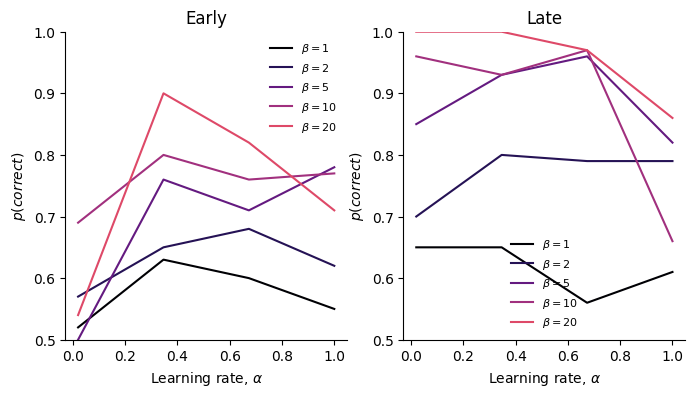

In [13]:
colors = plt.get_cmap('magma')(np.linspace(0, 0.6, len(betas)))

plt.figure(figsize=(8, 4), dpi=100)
plt.subplot(1, 2, 1)
plt.title('Early')
for ei, early in enumerate(np.mean(correct_early, axis=-1).T):
    plt.plot(alphas, early, color=colors[ei], label=rf'$\beta = {betas[ei]:.0f}$')
plt.xlabel(r'Learning rate, $\alpha$')
plt.ylabel(r'$p(correct)$')
plt.legend(frameon=False, fontsize=8)
plt.ylim(0.5, 1)

plt.subplot(1, 2, 2)
plt.title('Late')
for li, late in enumerate(np.mean(correct_late, axis=-1).T):
    plt.plot(alphas, late, color=colors[li], label=rf'$\beta = {betas[li]:.0f}$')
plt.xlabel(r'Learning rate, $\alpha$')
plt.ylabel(r'$p(correct)$')
plt.legend(frameon=False, fontsize=8)
plt.ylim(0.5, 1)

sns.despine()

How does performance change as a function of alpha and beta parameter values, for early and late trials?

The left graph shows that the learning rate is positively correlated with increases in early performance only for low $\beta$ values, or very low $\alpha$ values. For high $\beta$ values, there is a U-shaped relationship between learning rate and early speed of learning. The right graph shows that with high $\beta$ values, high learning rates negatively influence asymptotic behavior. Thus, both parameters interact to influence both the speed of learning and asymptotic performance.

*Conclusion*: This kind of analysis will allow you to see qualitative differences between models, so that making their predictions in the experimental setup different. If the behavior of different models is not qualitatively different, this is a sign that you should try to design a better experiment. While not always possible, distinguishing between models on the basis of qualitative patterns in the data is preferable to quantitative model comparison.

## 4. Parameter recovery

Previously, we used parameter recovery to test whether our models were working across a range of parameters.  Now, let's use parameter recovery to estimate the variability in our parameters based on the amount of data we have.  This can be useful before running experiments as a power analysis: how many trials do I need to collect from participants in order to get good estimates of my model parameters?  For this, we can use approximate parameters, perhaps those we obtained from preliminary data.  We can also try different parameters and see how that impacts the variability.  We'll focus on Rescorla-Wagner for now.

In [14]:
# Parameter recovery
repeats = 10
true_params = np.array([.1, 5])
sample_sizes = np.logspace(1, 3, 10).astype(int) # Values for T, should range from 1*10^1 to 1*10^3

recovered_params = np.empty((len(sample_sizes), repeats, len(true_params)))

# FILL ME IN!

/tmp/ipykernel_4181/1970803528.py:31: RuntimeWarning: overflow encountered in exp
  p = np.exp(beta * Q) / np.sum(np.exp(beta * Q))
/tmp/ipykernel_4181/1970803528.py:31: RuntimeWarning: invalid value encountered in divide
  p = np.exp(beta * Q) / np.sum(np.exp(beta * Q))


Now, let's plot.

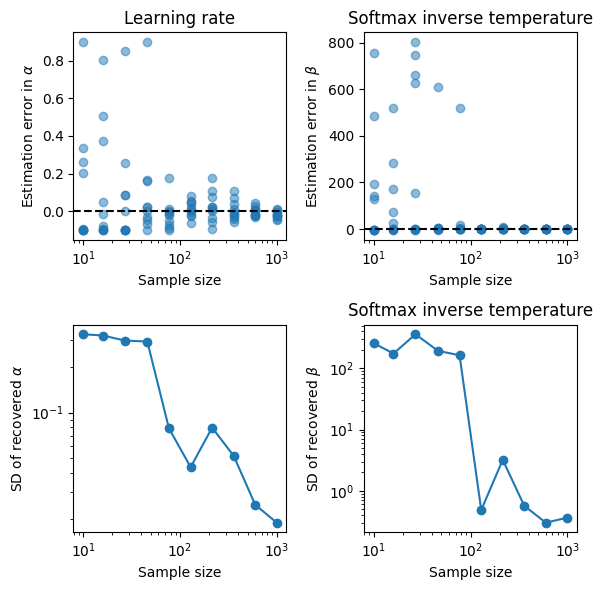

In [15]:
sample_size_grid = np.repeat(sample_sizes, repeats)
alpha_errors = (recovered_params[:, :, 0] - true_params[0]).ravel()
beta_errors = (recovered_params[:, :, 1] - true_params[1]).ravel()

plt.figure(figsize=(6, 6), dpi=100)
plt.subplot(2,2,1)
plt.title('Learning rate')
plt.scatter(sample_size_grid, alpha_errors, alpha=.5)
plt.axhline(0, color='k', linestyle='--')
plt.xscale('log')
plt.xlabel(r'Sample size')
plt.ylabel(r'Estimation error in $\alpha$')

ax = plt.subplot(2,2,2)
ax.set_title('Softmax inverse temperature')
ax.scatter(sample_size_grid, beta_errors, alpha=.5)
ax.axhline(0, color='k', linestyle='--')
ax.set_xscale('log')
ax.set_xlabel(r'Sample size')
ax.set_ylabel(r'Estimation error in $\beta$')

stdevs_alpha = np.std(recovered_params[:, :, 0], axis=1, ddof=1)
plt.subplot(2,2,3)
plt.plot(sample_sizes, stdevs_alpha, 'o-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Sample size')
plt.ylabel(r'SD of recovered $\alpha$')

stdevs_beta = np.std(recovered_params[:, :, 1], axis=1, ddof=1)
ax = plt.subplot(2,2,4)
ax.set_title('Softmax inverse temperature')
ax.plot(sample_sizes, stdevs_beta, 'o-')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Sample size')
ax.set_ylabel(r'SD of recovered $\beta$')

plt.tight_layout()

Do you observe a decrease in variability as the sample size goes up?

If these don't fall along a line, there could be many possible reasons:

- The model may have correlated (or dependent) parameters.  In an extreme case, if your model was $y = a + b + x$, then any increase in $a$ could be exactly offset by a decrease in $b$.  One way to look at this is to perform parameter recovery across a wide spectrum of parameters and look for correlations.
- The fitting algorithm could be failing to find the best parameterisation.  This could be because the algorithm is suboptimal, the ranges are too wide, or the starting guesses are not precise enough.
- There could be a bug in your likelihood or simulation code

## 5. Model recovery: confusion matrix

To illustrate model recovery, here we will simulate behavior of our three models on the two-armed bandits task.

As before, the means $\mu$ can be set at 0.2 and 0.8, and the number of trials at $T = 1000$. For each simulation, model parameters can be sampled randomly for each model.

Each simulated data set will then be fit to each of the given models, to determine which model fit best (according to BIC). This process will be repeated 100 times (number of "repetitions" or "counts") to compute the confusion matrix.

In [16]:
# Model comparison
num_trials = 1_000
num_counts = 10

Let's build a confusion matrix. It quantifies the probability that each model is the best fit to data generated from the other models. In a perfect world the confusion matrix will be the identity matrix, but in practice this is not always the case.

Rows represent generating models and columns represent best-fitting models. Because each row is normalized separately, an entry estimates P(best-fitting model | generating model). Each row should sum to one; columns are not posterior probabilities over generating models.

In [17]:
models = [wsls_model, rw_model, ck_model]
confusion_matrix = np.zeros((3, 3))

# FILL ME IN!

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


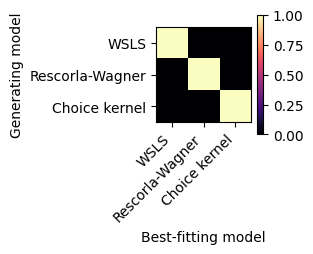

In [18]:
# normalize confusion matrix
confusion_matrix_norm = (
    confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)
)

# print values to see
print(confusion_matrix_norm)

# plot values
plt.figure(figsize=(3, 3), dpi=100)
plt.imshow(confusion_matrix_norm, vmin=0, vmax=1, cmap='magma')
plt.colorbar(shrink=0.7)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.yticks(range(len(model_names)), model_names)
plt.xlabel('Best-fitting model')
plt.ylabel('Generating model')
plt.tight_layout()

- Does your confusion matrix have large off-diagonal components? If so, this indicates that you have a problem with model recovery.  In other words, the models make similar predictions, so it may not be possible to tell the two models apart based on data.

- If you change the generating parameters, in particular the softmax inverse temperature, do you get a better confusion matrix?

You can observe that the confusion matrix can be so dependent on the simulating parameter values that it is crucial to match the simulation parameters to the fit parameters of your behavioral data (when you have some) as closely as possible. Models that are identifiable in one parameter regime may be impossible to distinguish in another regime.

A final note to remember: As with all model comparisons, it only tells you which model fits best of the models you considered. In and of itself, this is rather limited information as there are infinitely many other models that you did not consider. This makes it imperative to start with a good set of models initially, that rigorously capture the competing hypotheses.

## 6. RL-DDM (bonus!)

In the previous module, we looked at simulating and fitting DDMs.  DDMs give you a way to combine response time with choice in the same model.  In our Rescorla-Wagner models here, we only selected the probability of each choice, without considering the response time.  If we are fitting an RL model and also have response time information, it may be useful to use this information instead of discarding it.

This is the idea behind the RL-DDM: incorporating both choice and response time into a reinforcement learning model.  To do this, we start with our typical Rescorla-Wagner model.  These models have two important functions: the learning rule (e.g., Rescorla-Wagner) and the choice policy for determining the likelihood of each choice (e.g., softmax).  DDM will replace the choice policy: we will replace the softmax with a DDM.  When simulating, this also gives us a response time for each choice.  When computing the likelihood and fitting, the likelihood depends on a response time as well as a reward and choice for each trial.  We will let the drift rate be proportional to the difference in $Q_{right}-Q_{left}$, and fit the parameters of the DDM simultaneously with those for reinforcement learning.

First let's consider some example data:

In [21]:
%pip install pyddm
import pandas
import pyddm
import numpy as np
df = pandas.read_csv("https://raw.githubusercontent.com/bambschool/BAMB2025/master/Day_6_DDM/rl_ddm_data.csv")
df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 kB 1.2 MB/s eta 0:00:00


,choice,RT,trial,reward
0,1,0.318521,4,1
1,1,0.281707,5,1
2,1,0.628159,8,1
3,1,0.657423,11,1
4,1,0.504722,12,1
...,...,...,...,...
995,0,0.224363,990,0
996,0,0.425010,994,0
997,0,0.168368,995,0
998,0,0.226326,996,0


Notice that we have four columns: the trial number, the choice we make, the reward we get, and the RT of that choice.

To create an RL-DDM, the main thing we must do is define the goodness-of-fit. We can do this by simulating the Q values for each trial based only on the choices and rewards for those choices. Then, once we have Q values over time, we compute the likelihood for each trial by determining what the likelihood is for that choice.

First, let's write a function to compute the likelihood of a set of trials. Then, we'll incorporate it into the PyDDM model.

In [22]:
def rl_ddm_likelihood(trials, model, alpha):
    """Compute the likelihood of an RL-DDM model.

    `trials` should be a Pandas DataFrame with columns:
        "trial": 1-N trials in the session
        "choice": whether the right or left boundary was chosen
        "reward": did the agent receive a reward after making that choice
        "RT": the response time

    `model` should be a PyDDM model.  Assume all the parameters have been specified but it takes a condition "deltaq".
    `alpha` should be the RL learning rate parameter

    We do not need a beta parameter because the DDM takes care of the choice policy.
    """
    df = trials.sort_values('trial') # Make sure trials are in order
    qleft = [.5] # Start with estimate of .5 for Q_left and Q_right
    qright = [.5]
    loglikelihood = 0
    for i,row in df.iterrows(): # Can use the variables row['choice'], row['reward'], and row['RT']
        chose_left = row['choice'] <= 0
        # Solve the DDM model, plugging in the difference between Q values for deltaq
        sol = model.solve(conditions={"deltaq": qright[-1]-qleft[-1]})
        # Find the probability of making the given choice (left or right) at the given RT
        p = sol.evaluate(row['RT'], "left" if chose_left else "right")
        # Using the results, set new_qleft and new_qright to be the updated Q values
        if chose_left:
            # FILL ME IN!
        else: # Right choice
            # FILL ME IN!
        qleft.append(new_qleft)
        qright.append(new_qright)
        if not np.isfinite(p) or p <= 0:
            return np.inf
        loglikelihood += np.log(p)
    return -loglikelihood

Now, we can incorporate this into PyDDM with the following.

In [23]:
class LossRL(pyddm.LossFunction):
    name = "rl_loss"
    def loss(self, model):
        alpha = model.get_dependence("drift").alpha
        df = self.sample.to_pandas_dataframe()
        return rl_ddm_likelihood(df, model, alpha)

m = pyddm.gddm(drift=lambda deltaq,driftscale,alpha: deltaq*driftscale+0*alpha,
               noise=1,
               bound="B",
               nondecision="ndt",
               parameters={"driftscale": (-5, 5), "B": (.4, 3), "ndt": (0, .5), "alpha": (0,1)},
               conditions=["deltaq"],
               choice_names=("right", "left"),
               T_dur=2, dt=.01)

# And plot it for a few values of deltaq
import pyddm.plot
pyddm.plot.model_gui_jupyter(m, conditions={"deltaq": [-1, -.5, 0, .5, 1]})

Output()

And fit:

In [ ]:
sample = pyddm.Sample.from_pandas_dataframe(df, choice_column_name="choice", rt_column_name="RT", choice_names=("right", "left"))
m.fit(sample, lossfunction=LossRL, verbose=False)

Note that this will be fairly slow to fit - it may take a few minutes to an hour depending on your computer. In practice, there are ways we can make this faster. The main bottleneck is that we need to run the DDM separately for each trial, since each trial has a different ΔQ. One way to avoid this is to round the ΔQ values to the nearest .01. We lose a little bit of precision, but we can use cached values for many of our DDM evaluations instead of recomputing.  ([See here if you want to use this rounding approach.](https://pyddm.readthedocs.io/en/latest/cookbook/models.html#reinforcement-learning-ddm-rl-ddm))

The true underlying parameters used to simulate these data were driftscale=2, bound=.5, nondecision=.1, and alpha=.1. In general, alpha is fit with less precision than the DDM parameters. In practice, you would want to perform parameter recovery experiments to see how many participants, blocks, and trials you need to get good parameter estimates.

In [ ]:
# Show the fitted model
m.show()